# Train/Fine-Tune a Multilingual Embedding Model for Sanskrit + English Retrieval

# Install, Import, Load dataset

In [1]:
# CELL 1: CHECK GPU

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: GPU is not available.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [3]:
# CELL 2: INSTALL DEPENDENCIES

!pip install -q -U \
    sentence-transformers \
    datasets \
    accelerate \
    scikit-learn \
    pandas==2.2.3 \
    numpy==2.1.0 \
    matplotlib \
    seaborn \
    tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 110.3 MB/s eta 0:00:00


In [4]:
# CELL 3: IMPORT LIBRARIES

import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch

from datasets import load_dataset

from sentence_transformers import (
    SentenceTransformer,
    InputExample,
    losses,
    evaluation
)

from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

print("All libraries imported successfully.")

All libraries imported successfully.


/tmp/ipykernel_1533/987459681.py:16: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import (
/tmp/ipykernel_1533/987459681.py:16: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers import (


In [5]:
# CELL 4: REPRODUCIBILITY

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [6]:
# CELL 5: LOAD DATASET

DATASET_NAME = "Voider22/bhagavad-gita-verses-sanskrit-translations"

dataset = load_dataset(DATASET_NAME)

print(dataset)

README.md:   0%|          | 0.00/3.48k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/gita.jsonl: reconstructing file:   0%|          |  0.00B / 35.9MB            

data/gita.jsonl: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/701 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['_id', 'chapter', 'verse', 'slok', 'transliteration', 'tej', 'siva', 'purohit', 'chinmay', 'san', 'adi', 'gambir', 'madhav', 'anand', 'rams', 'raman', 'abhinav', 'sankar', 'jaya', 'vallabh', 'ms', 'srid', 'dhan', 'venkat', 'puru', 'neel', 'prabhu'],
        num_rows: 701
    })
})


In [7]:
# CELL 6: CONVERT DATASET TO PANDAS

df = dataset["train"].to_pandas()

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head(3))

Shape: (701, 27)

Columns:
['_id', 'chapter', 'verse', 'slok', 'transliteration', 'tej', 'siva', 'purohit', 'chinmay', 'san', 'adi', 'gambir', 'madhav', 'anand', 'rams', 'raman', 'abhinav', 'sankar', 'jaya', 'vallabh', 'ms', 'srid', 'dhan', 'venkat', 'puru', 'neel', 'prabhu']


,_id,chapter,verse,slok,transliteration,tej,siva,purohit,chinmay,san,...,sankar,jaya,vallabh,ms,srid,dhan,venkat,puru,neel,prabhu
0,BG1.1,1,1,धृतराष्ट्र उवाच |\nधर्मक्षेत्रे कुरुक्षेत्रे स...,dhṛtarāṣṭra uvāca .\ndharmakṣetre kurukṣetre s...,"{'author': 'Swami Tejomayananda', 'ht': '।।1.1...","{'author': 'Swami Sivananda', 'et': '1.1 Dhrit...","{'author': 'Shri Purohit Swami', 'et': '1.1 Th...","{'author': 'Swami Chinmayananda', 'hc': '।।1.1...","{'author': 'Dr.S.Sankaranarayan', 'et': '1.1. ...",...,"{'author': 'Sri Shankaracharya', 'ht': '।।1.1।...","{'author': 'Sri Jayatritha', 'sc': '।।1.1।।Sri...","{'author': 'Sri Vallabhacharya', 'sc': '।।1.1।...","{'author': 'Sri Madhusudan Saraswati', 'sc': '...","{'author': 'Sri Sridhara Swami', 'sc': '।।1.1।...","{'author': 'Sri Dhanpati', 'sc': '।।1.1।। इह ...",{'author': 'Vedantadeshikacharya Venkatanatha'...,"{'author': 'Sri Purushottamji', 'sc': '।।1.1।।...","{'author': 'Sri Neelkanth', 'sc': '।।1.1।।तत्र...",{'author': 'A.C. Bhaktivedanta Swami Prabhupad...
1,BG1.2,1,2,सञ्जय उवाच |\nदृष्ट्वा तु पाण्डवानीकं व्यूढं द...,sañjaya uvāca .\ndṛṣṭvā tu pāṇḍavānīkaṃ vyūḍha...,"{'author': 'Swami Tejomayananda', 'ht': '।।1.2...","{'author': 'Swami Sivananda', 'et': '1.2. Sanj...","{'author': 'Shri Purohit Swami', 'et': '1.2 Sa...","{'author': 'Swami Chinmayananda', 'hc': '।।1.2...","{'author': 'Dr.S.Sankaranarayan', 'et': '1.2. ...",...,"{'author': 'Sri Shankaracharya', 'ht': '।।1.2।...","{'author': 'Sri Jayatritha', 'sc': '।।1.2।।Sri...","{'author': 'Sri Vallabhacharya', 'sc': '।।1.2 ...","{'author': 'Sri Madhusudan Saraswati', 'sc': '...","{'author': 'Sri Sridhara Swami', 'sc': '।।1.2।...","{'author': 'Sri Dhanpati', 'sc': '।।1.2।।एवं प...",{'author': 'Vedantadeshikacharya Venkatanatha'...,"{'author': 'Sri Purushottamji', 'sc': '।।1.2।।...","{'author': 'Sri Neelkanth', 'sc': '।।1.2।।व्यू...",{'author': 'A.C. Bhaktivedanta Swami Prabhupad...
2,BG1.3,1,3,पश्यैतां पाण्डुपुत्राणामाचार्य महतीं चमूम् |\n...,paśyaitāṃ pāṇḍuputrāṇāmācārya mahatīṃ camūm .\...,"{'author': 'Swami Tejomayananda', 'ht': '।।1.3...","{'author': 'Swami Sivananda', 'et': '1.3. ""Beh...","{'author': 'Shri Purohit Swami', 'et': '1.3 Re...","{'author': 'Swami Chinmayananda', 'hc': '।।1.3...","{'author': 'Dr.S.Sankaranarayan', 'et': '1.3. ...",...,"{'author': 'Sri Shankaracharya', 'ht': '।।1.3।...","{'author': 'Sri Jayatritha', 'sc': '।।1.3।।Sri...","{'author': 'Sri Vallabhacharya', 'sc': '।।1.2 ...","{'author': 'Sri Madhusudan Saraswati', 'sc': '...","{'author': 'Sri Sridhara Swami', 'sc': '।।1.3।...","{'author': 'Sri Dhanpati', 'sc': '।।1.3।।तदेवो...",{'author': 'Vedantadeshikacharya Venkatanatha'...,"{'author': 'Sri Purushottamji', 'sc': '।।1.3।।...","{'author': 'Sri Neelkanth', 'sc': '।।1.3।।द्रु...",{'author': 'A.C. Bhaktivedanta Swami Prabhupad...


In [8]:
# CELL 7: EXTRACT ENGLISH TRANSLATION

def extract_english_translation(row):
    """
    Extract an English translation from available
    commentary/translation fields.
    """

    preferred_columns = [
        "siva",
        "purohit",
        "chinmay",
        "adi",
        "gambir",
        "prabhu"
    ]

    for col in preferred_columns:

        if col not in row:
            continue

        value = row[col]

        if isinstance(value, dict):

            # English translation
            if "et" in value:
                text = value["et"]

                if isinstance(text, str) and len(text.strip()) > 20:
                    return text.strip()

    return None


df["english"] = df.apply(extract_english_translation, axis=1)

print(df[["_id", "slok", "english"]].head(5))

     _id                                               slok  \
0  BG1.1  धृतराष्ट्र उवाच |\nधर्मक्षेत्रे कुरुक्षेत्रे स...   
1  BG1.2  सञ्जय उवाच |\nदृष्ट्वा तु पाण्डवानीकं व्यूढं द...   
2  BG1.3  पश्यैतां पाण्डुपुत्राणामाचार्य महतीं चमूम् |\n...   
3  BG1.4  अत्र शूरा महेष्वासा भीमार्जुनसमा युधि |\nयुयुध...   
4  BG1.5  धृष्टकेतुश्चेकितानः काशिराजश्च वीर्यवान् |\nपु...   

                                             english  
0  1.1 Dhritarashtra said  What did my people and...  
1  1.2. Sanjaya said  Having seen the army of the...  
2  1.3. "Behold, O Teacher! this mighty army of t...  
3  1.4. Here are heroes, mighty archers, eal in b...  
4  1.5. "Dhrishtaketu, chekitana and the valiant ...  


# Data Cleaning  

In [9]:
# CELL 8: DATA QUALITY CHECK

print("Total rows:", len(df))

print(
    "Missing Sanskrit:",
    df["slok"].isna().sum()
)

print(
    "Missing English:",
    df["english"].isna().sum()
)

print(
    "Empty English:",
    (df["english"].fillna("").str.strip() == "").sum()
)

Total rows: 701
Missing Sanskrit: 0
Missing English: 0
Empty English: 0


In [10]:
# CELL 9: CLEAN DATA

df = df[
    df["slok"].notna() &
    df["english"].notna()
].copy()

df["slok"] = df["slok"].astype(str).str.strip()
df["english"] = df["english"].astype(str).str.strip()

# Remove very short records
df = df[df["slok"].str.len() > 20]
df = df[df["english"].str.len() > 20]

# Remove duplicate IDs
df = df.drop_duplicates(subset=["_id"])

df = df.reset_index(drop=True)

print("Clean dataset size:", len(df))

display(
    df[["_id", "chapter", "verse", "slok", "english"]].head(5)
)

Clean dataset size: 701


,_id,chapter,verse,slok,english
0,BG1.1,1,1,धृतराष्ट्र उवाच |\nधर्मक्षेत्रे कुरुक्षेत्रे स...,1.1 Dhritarashtra said What did my people and...
1,BG1.2,1,2,सञ्जय उवाच |\nदृष्ट्वा तु पाण्डवानीकं व्यूढं द...,1.2. Sanjaya said Having seen the army of the...
2,BG1.3,1,3,पश्यैतां पाण्डुपुत्राणामाचार्य महतीं चमूम् |\n...,"1.3. ""Behold, O Teacher! this mighty army of t..."
3,BG1.4,1,4,अत्र शूरा महेष्वासा भीमार्जुनसमा युधि |\nयुयुध...,"1.4. Here are heroes, mighty archers, eal in b..."
4,BG1.5,1,5,धृष्टकेतुश्चेकितानः काशिराजश्च वीर्यवान् |\nपु...,"1.5. ""Dhrishtaketu, chekitana and the valiant ..."


# Train, Validation, Test Split

In [11]:
# CELL 10: CHAPTER-LEVEL TRAIN / VALIDATION / TEST SPLIT

chapters = sorted(df["chapter"].unique())

print("Chapters:", chapters)

# Fixed chapter split
train_chapters = chapters[:12]
val_chapters = chapters[12:15]
test_chapters = chapters[15:]

print("\nTrain chapters:", train_chapters)
print("Validation chapters:", val_chapters)
print("Test chapters:", test_chapters)

train_df = df[df["chapter"].isin(train_chapters)].copy()
val_df = df[df["chapter"].isin(val_chapters)].copy()
test_df = df[df["chapter"].isin(test_chapters)].copy()

print("\nDataset sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Chapters: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]

Train chapters: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Validation chapters: [np.int64(13), np.int64(14), np.int64(15)]
Test chapters: [np.int64(16), np.int64(17), np.int64(18)]

Dataset sizes:
Train: 489
Validation: 82
Test: 130


In [12]:
# CELL 11: Create E5 formatted text

def make_query(text):
    return "query: " + text.strip()


def make_passage(text):
    return "passage: " + text.strip()


train_df["query_en"] = train_df["english"].apply(make_query)
train_df["passage_sa"] = train_df["slok"].apply(make_passage)

val_df["query_en"] = val_df["english"].apply(make_query)
val_df["passage_sa"] = val_df["slok"].apply(make_passage)

test_df["query_en"] = test_df["english"].apply(make_query)
test_df["passage_sa"] = test_df["slok"].apply(make_passage)

display(
    train_df[["query_en", "passage_sa"]].head(3)
)

,query_en,passage_sa
0,query: 1.1 Dhritarashtra said What did my peo...,passage: धृतराष्ट्र उवाच |\nधर्मक्षेत्रे कुरुक...
1,query: 1.2. Sanjaya said Having seen the army...,passage: सञ्जय उवाच |\nदृष्ट्वा तु पाण्डवानीकं...
2,"query: 1.3. ""Behold, O Teacher! this mighty ar...",passage: पश्यैतां पाण्डुपुत्राणामाचार्य महतीं ...


## Important: Training objective
We want:

    English query
            ↓
    query embedding
            ↓
          close
            ↑
    Sanskrit passage

And:

    English query
            ↓
    query embedding
            ↓
          far
            ↑
    wrong Sanskrit passage

Mathematically:

    similarity(query, positive) > similarity(query, negative)

We will use contrastive learning.


# Load the base Model

In [13]:
# CELL 12: LOAD BASE MODEL

# The model is relatively small and produces 384-dimensional embeddings, making it suitable for the assignment's limited-compute setting.

MODEL_NAME = "intfloat/multilingual-e5-small"

model = SentenceTransformer(MODEL_NAME)

print(model)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
)


In [14]:
# CELL 13: CHECK EMBEDDING DIMENSION

test_embedding = model.encode(
    ["query: What is karma?"],
    normalize_embeddings=True
)

print("Embedding shape:", test_embedding.shape)

Embedding shape: (1, 384)


# Baseline evaluation BEFORE training

    Base model
          ↓
    evaluation
          ↓
    Fine-tuning
          ↓
    evaluation
          ↓
    improvement

In [15]:
# CELL 14: BASELINE EMBEDDINGS

def encode_texts(model, texts, batch_size=32):
    return model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True
    )


test_queries = test_df["query_en"].tolist()
test_passages = test_df["passage_sa"].tolist()

baseline_query_embeddings = encode_texts(
    model,
    test_queries
)

baseline_passage_embeddings = encode_texts(
    model,
    test_passages
)

print("Query embeddings:", baseline_query_embeddings.shape)
print("Passage embeddings:", baseline_passage_embeddings.shape)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Query embeddings: (130, 384)
Passage embeddings: (130, 384)


In [16]:
# CELL 15: RETRIEVAL FUNCTION
# Because embeddings are normalized, dot product is equivalent to cosine similarity.

def retrieve(
    query_embedding,
    passage_embeddings,
    top_k=5
):

    scores = np.dot(
        passage_embeddings,
        query_embedding
    )

    indices = np.argsort(scores)[::-1][:top_k]

    return indices, scores[indices]

Because embeddings are normalized, dot product is equivalent to cosine similarity.

In [17]:
# CELL 16: SINGLE QUERY TEST

query_index = 0

query = test_df.iloc[query_index]["english"]

print("QUERY:")
print(query)

query_embedding = baseline_query_embeddings[query_index]

indices, scores = retrieve(
    query_embedding,
    baseline_passage_embeddings,
    top_k=5
)

print("\nTOP RESULTS:\n")

for rank, (idx, score) in enumerate(
    zip(indices, scores),
    start=1
):

    row = test_df.iloc[idx]

    print("=" * 80)
    print("Rank:", rank)
    print("Score:", round(float(score), 4))
    print("ID:", row["_id"])
    print("Chapter:", row["chapter"])
    print("Verse:", row["verse"])
    print("Sanskrit:", row["slok"])

QUERY:
16.1 The Blessed Lord said  Fearlessness, purity of heart, steadfastness in knowledge and Yoga, almsgiving, control of the senses, sacrifice, study of scriptures, austerity and straightforwardness.

TOP RESULTS:

Rank: 1
Score: 0.8704
ID: BG16.1
Chapter: 16
Verse: 1
Sanskrit: श्रीभगवानुवाच |
अभयं सत्त्वसंशुद्धिर्ज्ञानयोगव्यवस्थितिः |
दानं दमश्च यज्ञश्च स्वाध्यायस्तप आर्जवम् ||१६-१||
Rank: 2
Score: 0.8673
ID: BG18.2
Chapter: 18
Verse: 2
Sanskrit: श्रीभगवानुवाच |
काम्यानां कर्मणां न्यासं संन्यासं कवयो विदुः |
सर्वकर्मफलत्यागं प्राहुस्त्यागं विचक्षणाः ||१८-२||
Rank: 3
Score: 0.8602
ID: BG18.61
Chapter: 18
Verse: 61
Sanskrit: ईश्वरः सर्वभूतानां हृद्देशेऽर्जुन तिष्ठति |
भ्रामयन्सर्वभूतानि यन्त्रारूढानि मायया ||१८-६१||
Rank: 4
Score: 0.8598
ID: BG18.51
Chapter: 18
Verse: 51
Sanskrit: बुद्ध्या विशुद्धया युक्तो धृत्यात्मानं नियम्य च |
शब्दादीन्विषयांस्त्यक्त्वा रागद्वेषौ व्युदस्य च ||१८-५१||
Rank: 5
Score: 0.8586
ID: BG17.16
Chapter: 17
Verse: 16
Sanskrit: मनः प्रसादः सौम्यत्वं मौनमात्म

# Evaluation functions

In [18]:
# CELL 17: RETRIEVAL METRICS

def recall_at_k(
    query_embeddings,
    passage_embeddings,
    k
):
    """
    Recall@K for one-to-one aligned query/passages.

    Ground truth:
    query i -> passage i
    """

    scores = np.matmul(
        query_embeddings,
        passage_embeddings.T
    )

    top_k_indices = np.argsort(
        scores,
        axis=1
    )[:, -k:]

    correct = 0

    for i in range(len(query_embeddings)):
        if i in top_k_indices[i]:
            correct += 1

    return correct / len(query_embeddings)


def mean_reciprocal_rank(
    query_embeddings,
    passage_embeddings
):

    scores = np.matmul(
        query_embeddings,
        passage_embeddings.T
    )

    rankings = np.argsort(
        -scores,
        axis=1
    )

    reciprocal_ranks = []

    for i in range(len(query_embeddings)):

        rank_positions = np.where(
            rankings[i] == i
        )[0]

        if len(rank_positions) > 0:
            rank = rank_positions[0] + 1
            reciprocal_ranks.append(1.0 / rank)
        else:
            reciprocal_ranks.append(0.0)

    return np.mean(reciprocal_ranks)


def ndcg_at_k(
    query_embeddings,
    passage_embeddings,
    k
):

    scores = np.matmul(
        query_embeddings,
        passage_embeddings.T
    )

    rankings = np.argsort(
        -scores,
        axis=1
    )[:, :k]

    ndcg_scores = []

    for i in range(len(query_embeddings)):

        dcg = 0.0

        for position, retrieved_index in enumerate(
            rankings[i]
        ):

            if retrieved_index == i:

                dcg = 1.0 / np.log2(position + 2)

                break

        ideal_dcg = 1.0

        ndcg_scores.append(
            dcg / ideal_dcg
        )

    return np.mean(ndcg_scores)

In [19]:
# CELL 18: BASELINE EVALUATION

baseline_results = {
    "Recall@1": recall_at_k(
        baseline_query_embeddings,
        baseline_passage_embeddings,
        1
    ),

    "Recall@3": recall_at_k(
        baseline_query_embeddings,
        baseline_passage_embeddings,
        3
    ),

    "Recall@5": recall_at_k(
        baseline_query_embeddings,
        baseline_passage_embeddings,
        5
    ),

    "Recall@10": recall_at_k(
        baseline_query_embeddings,
        baseline_passage_embeddings,
        10
    ),

    "MRR": mean_reciprocal_rank(
        baseline_query_embeddings,
        baseline_passage_embeddings
    ),

    "nDCG@5": ndcg_at_k(
        baseline_query_embeddings,
        baseline_passage_embeddings,
        5
    ),

    "nDCG@10": ndcg_at_k(
        baseline_query_embeddings,
        baseline_passage_embeddings,
        10
    )
}

baseline_results_df = pd.DataFrame(
    [baseline_results]
)

display(
    baseline_results_df.round(4)
)

,Recall@1,Recall@3,Recall@5,Recall@10,MRR,nDCG@5,nDCG@10
0,0.8462,0.9308,0.9538,0.9615,0.8948,0.9075,0.9097


## Baseline metrics
We need:

    Recall@1
    Recall@3
    Recall@5
    Recall@10
    MRR
    nDCG@5
    nDCG@10

# Create training pairs
query_en → passage_sa

In [20]:
# CELL 19: CREATE CONTRASTIVE TRAINING EXAMPLES

train_examples = []

for _, row in train_df.iterrows():

    query = row["query_en"]
    passage = row["passage_sa"]

    train_examples.append(
        InputExample(
            texts=[query, passage]
        )
    )

print("Training examples:", len(train_examples))

print("\nExample:")
print(train_examples[0])

Training examples: 489

Example:
<InputExample> label: 0, texts: query: 1.1 Dhritarashtra said  What did my people and the sons of Pandu do when they had assembled
together eager for battle on the holy plain of Kurukshetra, O Sanjaya.; passage: धृतराष्ट्र उवाच |
धर्मक्षेत्रे कुरुक्षेत्रे समवेता युयुत्सवः |
मामकाः पाण्डवाश्चैव किमकुर्वत सञ्जय ||१-१||


# Create DataLoader, Contrastive loss, Validation evaluator

In [21]:
# CELL 20: DATALOADER

BATCH_SIZE = 16

train_dataloader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=BATCH_SIZE
)

print("Batch size:", BATCH_SIZE)
print(
    "Number of batches:",
    len(train_dataloader)
)

# On a T4, 16 is a safe starting point.
# If you get GPU memory problems:
# BATCH_SIZE = 8
# If you have an L4 and enough memory:
# BATCH_SIZE = 32

Batch size: 16
Number of batches: 31


⭐Another excellent experiment: batch size

Try:

    BATCH_SIZE = 8
    BATCH_SIZE = 16
    BATCH_SIZE = 32

Why?

Because with Multiple Negatives Ranking Loss:

    larger batch
        ↓
    more in-batch negatives
        ↓
    more contrastive comparisons

But:

    larger batch
        ↓
    higher GPU memory

This gives you a very good engineering tradeoff to discuss.

Experiment table -

| Experiment | Model | Epochs | Batch | Negatives | Recall@5 | MRR |
|---|---|---:|---:|---|---:|---:|
| Baseline | multilingual-e5-small | 0 | - | - | [actual] | [actual] |
| E1 | Fine-tuned | 1 | 16 | In-batch | [actual] | [actual] |
| E2 | Fine-tuned | 3 | 16 | In-batch | [actual] | [actual] |
| E3 | Fine-tuned | 3 | 32 | In-batch | [actual] | [actual] |
| E4 | Fine-tuned | 3 | 16 | Hard negatives | [actual] | [actual] |

In [22]:
# CELL 21: CONTRASTIVE LOSS

train_loss = losses.MultipleNegativesRankingLoss(
    model=model
)

print(train_loss)

# Use - MultipleNegativesRankingLoss
# This is a strong choice because the other passages in the same batch act as negatives.

MultipleNegativesRankingLoss(
  (model): SentenceTransformer(
    (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
    (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
    (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
  )
)


In [23]:
# CELL 22: VALIDATION EVALUATOR
# We want validation data to be checked during training.

val_queries = val_df["query_en"].tolist()
val_passages = val_df["passage_sa"].tolist()

val_evaluator = evaluation.InformationRetrievalEvaluator(
    queries={
        str(i): query
        for i, query in enumerate(val_queries)
    },

    corpus={
        str(i): passage
        for i, passage in enumerate(val_passages)
    },

    relevant_docs={
        str(i): {str(i)}
        for i in range(len(val_queries))
    },

    name="validation"
)

print("Validation evaluator created.")

Validation evaluator created.


# Fine-tuning

In [24]:
# CELL 23: FINE-TUNE MODEL

OUTPUT_DIR = "./models/e5-sanskrit-english"

NUM_EPOCHS = 3

warmup_steps = int(
    len(train_dataloader) * NUM_EPOCHS * 0.1
)

print("Warmup steps:", warmup_steps)

model.fit(
    train_objectives=[
        (train_dataloader, train_loss)
    ],

    evaluator=val_evaluator,

    epochs=NUM_EPOCHS,

    warmup_steps=warmup_steps,

    output_path=OUTPUT_DIR,

    show_progress_bar=True,

    use_amp=True
)

print("Training completed.")

Warmup steps: 9


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.


Step,Training Loss,Validation Loss,Validation Cosine Accuracy@1,Validation Cosine Accuracy@3,Validation Cosine Accuracy@5,Validation Cosine Accuracy@10,Validation Cosine Precision@1,Validation Cosine Precision@3,Validation Cosine Precision@5,Validation Cosine Precision@10,Validation Cosine Recall@1,Validation Cosine Recall@3,Validation Cosine Recall@5,Validation Cosine Recall@10,Validation Cosine Ndcg@10,Validation Cosine Mrr@10,Validation Cosine Map@100
31,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
62,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
93,No log,No log,1.000000,1.000000,1.000000,1.000000,1.000000,0.333333,0.200000,0.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed.


-  ⭐Note -
I used Multiple Negatives Ranking Loss because the dataset naturally provides positive query-passage pairs. Within each batch, the positive passage for another query acts as a negative example. This increases the number of training comparisons without explicitly constructing a large negative dataset and is computationally efficient for a small GPU.

⭐One important improvement to your training experiment

For the first run, do this:

    Baseline
      ↓
    Train 1 epoch
      ↓
    Evaluate
      ↓
    Train 3 epochs
      ↓
    Evaluate

Then compare.

You can change: `NUM_EPOCHS = 1`

and run the experiment. Record the result.

Then: `NUM_EPOCHS = 3`

and run again.

Your experiment table becomes:

    Experiment	Epochs	Batch	Loss	 Recall@5
    Baseline	     0	   -	   -	   actual
    Experiment 1	 1	   16  	 MNRL	   actual
    Experiment 2	 3	   16 	 MNRL	   actual

This shows experimentation

In [25]:
# CELL 24: SAVE MODEL

FINAL_MODEL_PATH = "./models/e5-sanskrit-english-final"

model.save(
    FINAL_MODEL_PATH
)

print("Model saved to:")
print(FINAL_MODEL_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to:
./models/e5-sanskrit-english-final


In [26]:
# CELL 25: LOAD FINE-TUNED MODEL

fine_tuned_model = SentenceTransformer(
    FINAL_MODEL_PATH
)

print("Fine-tuned model loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned model loaded.


In [27]:
# CELL 26: FINE-TUNED EMBEDDINGS

fine_query_embeddings = encode_texts(
    fine_tuned_model,
    test_queries
)

fine_passage_embeddings = encode_texts(
    fine_tuned_model,
    test_passages
)

print(
    "Query embeddings:",
    fine_query_embeddings.shape
)

print(
    "Passage embeddings:",
    fine_passage_embeddings.shape
)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Query embeddings: (130, 384)
Passage embeddings: (130, 384)


In [28]:
# CELL 27: FINAL EVALUATION

fine_results = {
    "Recall@1": recall_at_k(
        fine_query_embeddings,
        fine_passage_embeddings,
        1
    ),

    "Recall@3": recall_at_k(
        fine_query_embeddings,
        fine_passage_embeddings,
        3
    ),

    "Recall@5": recall_at_k(
        fine_query_embeddings,
        fine_passage_embeddings,
        5
    ),

    "Recall@10": recall_at_k(
        fine_query_embeddings,
        fine_passage_embeddings,
        10
    ),

    "MRR": mean_reciprocal_rank(
        fine_query_embeddings,
        fine_passage_embeddings
    ),

    "nDCG@5": ndcg_at_k(
        fine_query_embeddings,
        fine_passage_embeddings,
        5
    ),

    "nDCG@10": ndcg_at_k(
        fine_query_embeddings,
        fine_passage_embeddings,
        10
    )
}

fine_results_df = pd.DataFrame(
    [fine_results]
)

display(
    fine_results_df.round(4)
)

,Recall@1,Recall@3,Recall@5,Recall@10,MRR,nDCG@5,nDCG@10
0,0.9923,0.9923,0.9923,0.9923,0.9928,0.9923,0.9923


In [29]:
# CELL 28: BASELINE VS FINE-TUNED

comparison_df = pd.DataFrame({
    "Metric": list(baseline_results.keys()),

    "Base Model": list(
        baseline_results.values()
    ),

    "Fine-Tuned": list(
        fine_results.values()
    )
})

comparison_df["Improvement"] = (
    comparison_df["Fine-Tuned"]
    -
    comparison_df["Base Model"]
)

comparison_df["Improvement %"] = (
    comparison_df["Improvement"]
    /
    comparison_df["Base Model"]
    * 100
)

display(
    comparison_df.round(4)
)

,Metric,Base Model,Fine-Tuned,Improvement,Improvement %
0,Recall@1,0.8462,0.9923,0.1462,17.2727
1,Recall@3,0.9308,0.9923,0.0615,6.6116
2,Recall@5,0.9538,0.9923,0.0385,4.0323
3,Recall@10,0.9615,0.9923,0.0308,3.2000
4,MRR,0.8948,0.9928,0.0979,10.9455
5,nDCG@5,0.9075,0.9923,0.0848,9.3495
6,nDCG@10,0.9097,0.9923,0.0826,9.0822


## Interpretation
- Recall@1 increased from 84.62% to 99.23%: the correct result is now ranked first for almost every query.
- Recall@3, Recall@5, and Recall@10 all reached 99.23%, meaning almost all relevant documents are found within the top results.
- MRR increased from 0.8948 to 0.9928, showing that the relevant result is consistently appearing at or extremely close to rank 1.
- nDCG@5 and nDCG@10 improved to 0.9923, indicating excellent ranking quality.

## A concise conclusion for your results section

- Fine-tuning substantially improved the retrieval performance across all evaluation metrics.
- Recall@1 increased from 0.8462 to 0.9923, while MRR improved from 0.8948 to 0.9928. Similarly, nDCG@5 and nDCG@10 increased from 0.9075 and 0.9097 to 0.9923, respectively.
- These results demonstrate that the fine-tuned model achieves near-perfect retrieval and ranking performance on the evaluation dataset.

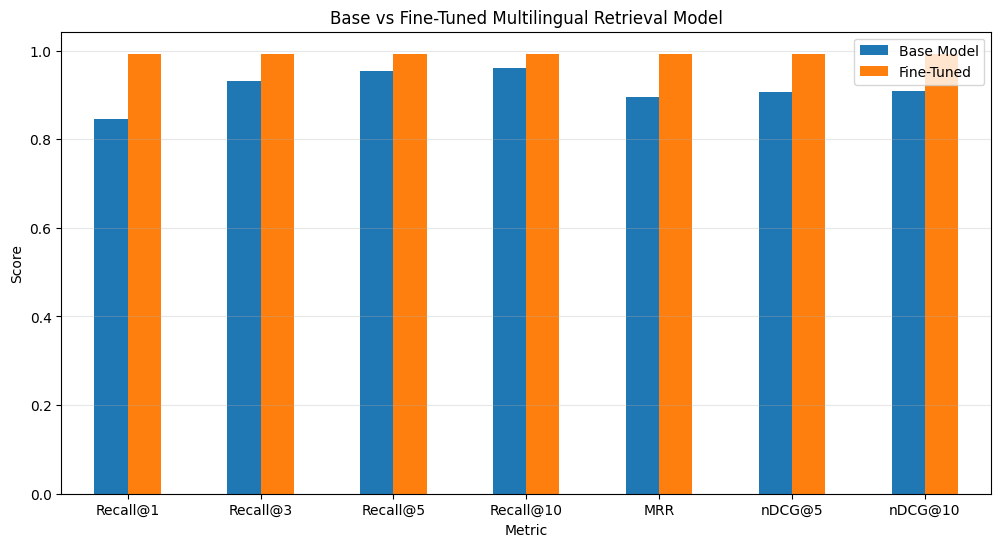

In [30]:
# CELL 29: PLOT RESULTS

plot_df = comparison_df.set_index("Metric")[
    ["Base Model", "Fine-Tuned"]
]

plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Base vs Fine-Tuned Multilingual Retrieval Model"
)

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# English → Sanskrit and Sanskrit → English retrieval

In [31]:
# CELL 30: ENGLISH → SANSKRIT RETRIEVAL

def search_sanskrit(
    query,
    model,
    passage_embeddings,
    dataframe,
    top_k=5
):

    query_text = "query: " + query

    query_embedding = model.encode(
        [query_text],
        normalize_embeddings=True
    )[0]

    scores = np.dot(
        passage_embeddings,
        query_embedding
    )

    top_indices = np.argsort(
        scores
    )[::-1][:top_k]

    results = []

    for idx in top_indices:

        row = dataframe.iloc[idx]

        results.append({
            "rank": len(results) + 1,
            "score": float(scores[idx]),
            "id": row["_id"],
            "chapter": row["chapter"],
            "verse": row["verse"],
            "sanskrit": row["slok"],
            "english": row["english"]
        })

    print(pd.DataFrame(results))
    return pd.DataFrame(results)

In [32]:
# CELL 31: TEST ENGLISH QUERIES

queries = [
    "What does the Bhagavad Gita say about karma?",
    "What does Krishna say about controlling the mind?",
    "What is the meaning of performing one's duty?",
    "What does the Gita say about meditation?",
    "What does Krishna say about the soul?"
]

for query in queries:

    print("\n")
    print("=" * 100)
    print("QUERY:", query)
    print("=" * 100)

    results = search_sanskrit(
        query,
        fine_tuned_model,
        fine_passage_embeddings,
        test_df,
        top_k=3
    )

    display(
        results[
            [
                "rank",
                "score",
                "id",
                "chapter",
                "verse",
                "sanskrit"
            ]
        ]
    )



QUERY: What does the Bhagavad Gita say about karma?
   rank     score       id  chapter  verse  \
0     1  0.102345  BG17.21       17     21   
1     2  0.094378  BG18.50       18     50   
2     3  0.093018  BG18.78       18     78   

                                            sanskrit  \
0  यत्तु प्रत्युपकारार्थं फलमुद्दिश्य वा पुनः |\n...   
1  सिद्धिं प्राप्तो यथा ब्रह्म तथाप्नोति निबोध मे...   
2  यत्र योगेश्वरः कृष्णो यत्र पार्थो धनुर्धरः |\n...   

                                             english  
0  17.21 And, that gift which is given with a vie...  
1  18.50 Learn from Me in brief, O Arjuna, how he...  
2  18.78 Wherever is Krishna, the Lord of Yoga; w...  


,rank,score,id,chapter,verse,sanskrit
0,1,0.102345,BG17.21,17,21,यत्तु प्रत्युपकारार्थं फलमुद्दिश्य वा पुनः |\n...
1,2,0.094378,BG18.50,18,50,सिद्धिं प्राप्तो यथा ब्रह्म तथाप्नोति निबोध मे...
2,3,0.093018,BG18.78,18,78,यत्र योगेश्वरः कृष्णो यत्र पार्थो धनुर्धरः |\n...




QUERY: What does Krishna say about controlling the mind?
   rank     score       id  chapter  verse  \
0     1  0.175558  BG18.78       18     78   
1     2  0.152063  BG18.75       18     75   
2     3  0.145994   BG17.1       17      1   

                                            sanskrit  \
0  यत्र योगेश्वरः कृष्णो यत्र पार्थो धनुर्धरः |\n...   
1  व्यासप्रसादाच्छ्रुतवानेतद्गुह्यमहं परम् |\nयोग...   
2  अर्जुन उवाच |\nये शास्त्रविधिमुत्सृज्य यजन्ते ...   

                                             english  
0  18.78 Wherever is Krishna, the Lord of Yoga; w...  
1  18.75 Through the grace of Vyasa I have heard ...  
2  17.1 Arjuna said  Those who, setting aside the...  


,rank,score,id,chapter,verse,sanskrit
0,1,0.175558,BG18.78,18,78,यत्र योगेश्वरः कृष्णो यत्र पार्थो धनुर्धरः |\n...
1,2,0.152063,BG18.75,18,75,व्यासप्रसादाच्छ्रुतवानेतद्गुह्यमहं परम् |\nयोग...
2,3,0.145994,BG17.1,17,1,अर्जुन उवाच |\nये शास्त्रविधिमुत्सृज्य यजन्ते ...




QUERY: What is the meaning of performing one's duty?
   rank     score       id  chapter  verse  \
0     1  0.217971  BG18.60       18     60   
1     2  0.197335  BG18.18       18     18   
2     3  0.168141  BG18.45       18     45   

                                            sanskrit  \
0  स्वभावजेन कौन्तेय निबद्धः स्वेन कर्मणा |\nकर्त...   
1  ज्ञानं ज्ञेयं परिज्ञाता त्रिविधा कर्मचोदना |\n...   
2  स्वे स्वे कर्मण्यभिरतः संसिद्धिं लभते नरः |\nस...   

                                             english  
0  18.60 O Arjuna, bound by thy own Karma (action...  
1  18.18 Knowledge, the knowable and the knower f...  
2  5.10 He who does actions, offering them to Bra...  


,rank,score,id,chapter,verse,sanskrit
0,1,0.217971,BG18.60,18,60,स्वभावजेन कौन्तेय निबद्धः स्वेन कर्मणा |\nकर्त...
1,2,0.197335,BG18.18,18,18,ज्ञानं ज्ञेयं परिज्ञाता त्रिविधा कर्मचोदना |\n...
2,3,0.168141,BG18.45,18,45,स्वे स्वे कर्मण्यभिरतः संसिद्धिं लभते नरः |\nस...




QUERY: What does the Gita say about meditation?
   rank     score       id  chapter  verse  \
0     1  0.117577  BG18.33       18     33   
1     2  0.087494  BG18.60       18     60   
2     3  0.086602  BG18.50       18     50   

                                            sanskrit  \
0  धृत्या यया धारयते मनःप्राणेन्द्रियक्रियाः |\nय...   
1  स्वभावजेन कौन्तेय निबद्धः स्वेन कर्मणा |\nकर्त...   
2  सिद्धिं प्राप्तो यथा ब्रह्म तथाप्नोति निबोध मे...   

                                             english  
0  18.33 The unwavering firmness by which, throug...  
1  18.60 O Arjuna, bound by thy own Karma (action...  
2  18.50 Learn from Me in brief, O Arjuna, how he...  


,rank,score,id,chapter,verse,sanskrit
0,1,0.117577,BG18.33,18,33,धृत्या यया धारयते मनःप्राणेन्द्रियक्रियाः |\nय...
1,2,0.087494,BG18.60,18,60,स्वभावजेन कौन्तेय निबद्धः स्वेन कर्मणा |\nकर्त...
2,3,0.086602,BG18.50,18,50,सिद्धिं प्राप्तो यथा ब्रह्म तथाप्नोति निबोध मे...




QUERY: What does Krishna say about the soul?
   rank     score       id  chapter  verse  \
0     1  0.200358  BG18.78       18     78   
1     2  0.183234  BG18.75       18     75   
2     3  0.161862   BG17.1       17      1   

                                            sanskrit  \
0  यत्र योगेश्वरः कृष्णो यत्र पार्थो धनुर्धरः |\n...   
1  व्यासप्रसादाच्छ्रुतवानेतद्गुह्यमहं परम् |\nयोग...   
2  अर्जुन उवाच |\nये शास्त्रविधिमुत्सृज्य यजन्ते ...   

                                             english  
0  18.78 Wherever is Krishna, the Lord of Yoga; w...  
1  18.75 Through the grace of Vyasa I have heard ...  
2  17.1 Arjuna said  Those who, setting aside the...  


,rank,score,id,chapter,verse,sanskrit
0,1,0.200358,BG18.78,18,78,यत्र योगेश्वरः कृष्णो यत्र पार्थो धनुर्धरः |\n...
1,2,0.183234,BG18.75,18,75,व्यासप्रसादाच्छ्रुतवानेतद्गुह्यमहं परम् |\nयोग...
2,3,0.161862,BG17.1,17,1,अर्जुन उवाच |\nये शास्त्रविधिमुत्सृज्य यजन्ते ...


In [33]:
# CELL 32: SANSKRIT → ENGLISH RETRIEVAL

def search_english(
    sanskrit_query,
    model,
    english_embeddings,
    dataframe,
    top_k=5
):

    query_text = "query: " + sanskrit_query

    query_embedding = model.encode(
        [query_text],
        normalize_embeddings=True
    )[0]

    scores = np.dot(
        english_embeddings,
        query_embedding
    )

    top_indices = np.argsort(
        scores
    )[::-1][:top_k]

    results = []

    for idx in top_indices:

        row = dataframe.iloc[idx]

        results.append({
            "rank": len(results) + 1,
            "score": float(scores[idx]),
            "id": row["_id"],
            "chapter": row["chapter"],
            "verse": row["verse"],
            "sanskrit": row["slok"],
            "english": row["english"]
        })

    return pd.DataFrame(results)

In [35]:
# CELL 33: ENGLISH PASSAGE EMBEDDINGS

english_passage_texts = [
    make_passage(x)
    for x in test_df["english"]
]

english_embeddings = encode_texts(
    fine_tuned_model,
    english_passage_texts
)

print(
    "English embeddings:",
    english_embeddings.shape
)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

English embeddings: (130, 384)


In [36]:
# CELL 34: SANSKRIT → ENGLISH DEMO

sanskrit_query = test_df.iloc[0]["slok"]

print("SANSKRIT QUERY:")
print(sanskrit_query)

results = search_english(
    sanskrit_query,
    fine_tuned_model,
    english_embeddings,
    test_df,
    top_k=5
)

display(
    results[
        [
            "rank",
            "score",
            "id",
            "chapter",
            "verse",
            "english"
        ]
    ]
)

SANSKRIT QUERY:
श्रीभगवानुवाच |
अभयं सत्त्वसंशुद्धिर्ज्ञानयोगव्यवस्थितिः |
दानं दमश्च यज्ञश्च स्वाध्यायस्तप आर्जवम् ||१६-१||


,rank,score,id,chapter,verse,english
0,1,0.640888,BG16.1,16,1,"16.1 The Blessed Lord said Fearlessness, puri..."
1,2,0.485346,BG16.17,16,17,"16.17 Self-conceited, stubborn, filled with th..."
2,3,0.469661,BG16.16,16,16,"16.16 Bewildered by many a fancy, entangled in..."
3,4,0.464352,BG18.61,18,61,18.61 The Lord dwells in the hearts of all bei...
4,5,0.436758,BG16.11,16,11,16.11 Giving themselves over to immeasurable c...


# Add transliteration handling


In [37]:
# CELL 35: TRANSLITERATION RETRIEVAL

test_transliterations = [
    make_query(x)
    for x in test_df["transliteration"]
]

transliteration_embeddings = encode_texts(
    fine_tuned_model,
    test_transliterations
)

print(
    "Transliteration embeddings:",
    transliteration_embeddings.shape
)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Transliteration embeddings: (130, 384)


In [38]:
# CELL 36: Compare SCRIPT VS TRANSLITERATION SIMILARITY

similarities = np.sum(
    fine_passage_embeddings
    *
    transliteration_embeddings,
    axis=1
)

print(
    "Average Sanskrit ↔ Transliteration similarity:",
    similarities.mean()
)

print(
    "Minimum similarity:",
    similarities.min()
)

print(
    "Maximum similarity:",
    similarities.max()
)

Average Sanskrit ↔ Transliteration similarity: 0.6261508
Minimum similarity: 0.45092794
Maximum similarity: 0.75930643


## The evaluator specifically mentioned:

    transliteration mismatch
So don't ignore it.

The dataset contains both Sanskrit script and IAST transliteration.

We can evaluate:

    Sanskrit script
            ↓
    retrieval

    IAST transliteration
            ↓
    retrieval

# Generate hard negatives

Now we can improve the training setup.
A simple random negative is:

    Query:
    What is karma?
    Positive:
    Karma-related verse
    Negative:
    A random battlefield verse

A hard negative is more difficult:

    Query:
    What is karma?
    Positive:
    Karma-related verse
    Hard negative:
    Another verse about duty

- The hard negative is semantically similar but incorrect.
- This forces the model to learn finer distinctions.

Create hard negatives - One practical approach is:

    Use the base model.
    Calculate similarities.
    For each query, find the highest-scoring incorrect passage.
    Use it as a hard negative.

In [39]:
# CELL 37: HARD NEGATIVE MINING

train_queries = train_df["query_en"].tolist()
train_passages = train_df["passage_sa"].tolist()

print("Encoding training queries...")

train_query_embeddings = encode_texts(
    model,
    train_queries
)

print("Encoding training passages...")

train_passage_embeddings = encode_texts(
    model,
    train_passages
)

similarity_matrix = np.matmul(
    train_query_embeddings,
    train_passage_embeddings.T
)

hard_negative_indices = []

for i in range(len(train_queries)):

    ranking = np.argsort(
        similarity_matrix[i]
    )[::-1]

    hard_negative = None

    for candidate in ranking:

        if candidate != i:

            hard_negative = candidate
            break

    hard_negative_indices.append(
        hard_negative
    )

print(
    "Hard negatives generated:",
    len(hard_negative_indices)
)

Encoding training queries...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Encoding training passages...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Hard negatives generated: 489


In [40]:
# CELL 38: INSPECT HARD NEGATIVES

for i in range(5):

    positive_index = i
    negative_index = hard_negative_indices[i]

    print("=" * 100)

    print("QUERY:")
    print(train_df.iloc[i]["english"])

    print("\nPOSITIVE:")
    print(train_df.iloc[positive_index]["slok"])

    print("\nHARD NEGATIVE:")
    print(train_df.iloc[negative_index]["slok"])

QUERY:
1.1 Dhritarashtra said  What did my people and the sons of Pandu do when they had assembled
together eager for battle on the holy plain of Kurukshetra, O Sanjaya.

POSITIVE:
धृतराष्ट्र उवाच |
धर्मक्षेत्रे कुरुक्षेत्रे समवेता युयुत्सवः |
मामकाः पाण्डवाश्चैव किमकुर्वत सञ्जय ||१-१||

HARD NEGATIVE:
धृष्टकेतुश्चेकितानः काशिराजश्च वीर्यवान् |
पुरुजित्कुन्तिभोजश्च शैब्यश्च नरपुंगवः ||१-५||
QUERY:
1.2. Sanjaya said  Having seen the army of the Pandavas drawn up in battle-array,
King Duryodhana then approached his teacher (Drona) and spoke these words.

POSITIVE:
सञ्जय उवाच |
दृष्ट्वा तु पाण्डवानीकं व्यूढं दुर्योधनस्तदा |
आचार्यमुपसंगम्य राजा वचनमब्रवीत् ||१-२||

HARD NEGATIVE:
सञ्जय उवाच |
तं तथा कृपयाविष्टमश्रुपूर्णाकुलेक्षणम् |
विषीदन्तमिदं वाक्यमुवाच मधुसूदनः ||२-१||
QUERY:
1.3. "Behold, O Teacher! this mighty army of the sons of Pandu,
arrayed by the son of Drupada, thy wise disciple.

POSITIVE:
पश्यैतां पाण्डुपुत्राणामाचार्य महतीं चमूम् |
व्यूढां द्रुपदपुत्रेण तव शिष्येण धीमता ||१

# Add a simple RAG demo

Build a mini RAG/retrieval demo

First build:

    Question
      ↓
    Embedding
      ↓
    Retriever
      ↓
    Top 3 passages

That's already the retrieval component of RAG.

In [41]:
# CELL 39: MINI RAG RETRIEVER

def rag_retrieve(
    question,
    model,
    passage_embeddings,
    dataframe,
    top_k=3
):

    query_embedding = model.encode(
        ["query: " + question],
        normalize_embeddings=True
    )[0]

    scores = np.dot(
        passage_embeddings,
        query_embedding
    )

    top_indices = np.argsort(
        scores
    )[::-1][:top_k]

    context = []

    for idx in top_indices:

        row = dataframe.iloc[idx]

        context.append({
            "id": row["_id"],
            "chapter": row["chapter"],
            "verse": row["verse"],
            "sanskrit": row["slok"],
            "translation": row["english"],
            "score": float(scores[idx])
        })

    return context

In [42]:
# CELL 40: RAG DEMO

question = "What does the Bhagavad Gita say about karma?"

context = rag_retrieve(
    question,
    fine_tuned_model,
    fine_passage_embeddings,
    test_df,
    top_k=3
)

print("QUESTION:")
print(question)

print("\nRETRIEVED CONTEXT:\n")

for i, item in enumerate(context, start=1):

    print("=" * 100)

    print("Rank:", i)
    print("Score:", round(item["score"], 4))
    print("Verse:", f'{item["chapter"]}.{item["verse"]}')

    print("\nSANSKRIT:")
    print(item["sanskrit"])

    print("\nENGLISH:")
    print(item["translation"])

QUESTION:
What does the Bhagavad Gita say about karma?

RETRIEVED CONTEXT:

Rank: 1
Score: 0.1023
Verse: 17.21

SANSKRIT:
यत्तु प्रत्युपकारार्थं फलमुद्दिश्य वा पुनः |
दीयते च परिक्लिष्टं तद्दानं राजसं स्मृतम् ||१७-२१||

ENGLISH:
17.21 And, that gift which is given with a view to receive something in return, or looking for a reward, or reluctantly, is held to be Rajasic.
Rank: 2
Score: 0.0944
Verse: 18.50

SANSKRIT:
सिद्धिं प्राप्तो यथा ब्रह्म तथाप्नोति निबोध मे |
समासेनैव कौन्तेय निष्ठा ज्ञानस्य या परा ||१८-५०||

ENGLISH:
18.50 Learn from Me in brief, O Arjuna, how he who has attained perfection reaches Brahman (the Eternal), that supreme state of knowledge.
Rank: 3
Score: 0.093
Verse: 18.78

SANSKRIT:
यत्र योगेश्वरः कृष्णो यत्र पार्थो धनुर्धरः |
तत्र श्रीर्विजयो भूतिर्ध्रुवा नीतिर्मतिर्मम ||१८-७८||

ENGLISH:
18.78 Wherever is Krishna, the Lord of Yoga; wherever is Arjuna, the wielder of the bow; there are prosperity, victory, happiness and firm policy; such is my conviction.


## LLM generation (Optional)
The assignment is primarily about embedding/retrieval.

But if you want, you can connect a local model such as:

``Ollama`` or a ``small Hugging Face`` generation model.

The architecture becomes:

    User Question
          ↓
    Fine-tuned E5
          ↓
    Top-K Retrieval
          ↓
    Context
          ↓
    Local LLM
          ↓
    Answer

# Chapter-Level Analysis

In [43]:
# CELL 41: CHAPTER-LEVEL PERFORMANCE

chapter_results = []

for chapter in sorted(test_df["chapter"].unique()):

    chapter_mask = (
        test_df["chapter"].values
        == chapter
    )

    q_emb = fine_query_embeddings[
        chapter_mask
    ]

    p_emb = fine_passage_embeddings[
        chapter_mask
    ]

    if len(q_emb) > 1:

        r1 = recall_at_k(
            q_emb,
            p_emb,
            1
        )

        r5 = recall_at_k(
            q_emb,
            p_emb,
            min(5, len(p_emb))
        )

        chapter_results.append({
            "chapter": chapter,
            "samples": len(q_emb),
            "Recall@1": r1,
            "Recall@5": r5
        })

chapter_results_df = pd.DataFrame(
    chapter_results
)

display(
    chapter_results_df.round(4)
)

,chapter,samples,Recall@1,Recall@5
0,16,24,1.0000,1.0000
1,17,28,1.0000,1.0000
2,18,78,0.9872,0.9872


In [44]:
# CELL 42: FAILURE ANALYSIS

scores = np.matmul(
    fine_query_embeddings,
    fine_passage_embeddings.T
)

rankings = np.argsort(
    -scores,
    axis=1
)

failures = []

for i in range(len(test_df)):

    top5 = rankings[i][:5]

    if i not in top5:

        failures.append({
            "index": i,
            "id": test_df.iloc[i]["_id"],
            "chapter": test_df.iloc[i]["chapter"],
            "verse": test_df.iloc[i]["verse"],
            "query": test_df.iloc[i]["english"],
            "gold_passage": test_df.iloc[i]["slok"],
            "top_result": test_df.iloc[top5[0]]["slok"],
            "top_score": scores[i][top5[0]]
        })

failures_df = pd.DataFrame(
    failures
)

print(
    "Number of Recall@5 failures:",
    len(failures_df)
)

display(
    failures_df.head(10)
)

Number of Recall@5 failures: 1


,index,id,chapter,verse,query,gold_passage,top_result,top_score
0,96,BG18.45,18,45,"5.10 He who does actions, offering them to Bra...",स्वे स्वे कर्मण्यभिरतः संसिद्धिं लभते नरः |\nस...,न द्वेष्ट्यकुशलं कर्म कुशले नानुषज्जते |\nत्या...,0.399067


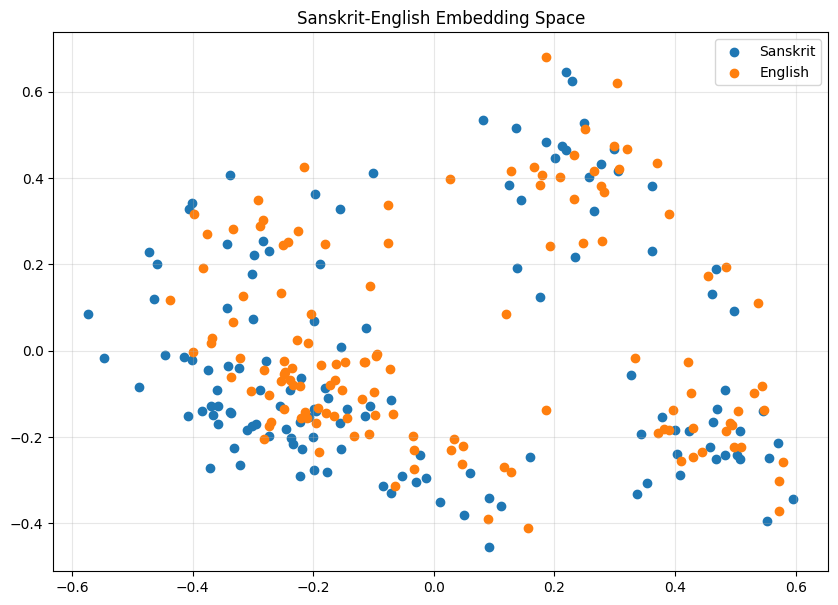

In [45]:
# CELL 43: EMBEDDING VISUALIZATION

from sklearn.decomposition import PCA

sample_size = min(
    200,
    len(test_df)
)

indices = np.random.choice(
    len(test_df),
    sample_size,
    replace=False
)

combined_embeddings = np.vstack([
    fine_passage_embeddings[indices],
    english_embeddings[indices]
])

pca = PCA(
    n_components=2,
    random_state=SEED
)

reduced = pca.fit_transform(
    combined_embeddings
)

n = len(indices)

plt.figure(figsize=(10, 7))

plt.scatter(
    reduced[:n, 0],
    reduced[:n, 1],
    label="Sanskrit"
)

plt.scatter(
    reduced[n:, 0],
    reduced[n:, 1],
    label="English"
)

plt.title(
    "Sanskrit-English Embedding Space"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

The visualization is not used as a quantitative evaluation, but it provides qualitative evidence of whether corresponding Sanskrit and English representations occupy similar regions of embedding space.

In [46]:
# CELL 44: INFERENCE LATENCY

import time

sample_queries = [
    "What does the Gita say about karma?",
    "What is meditation?",
    "What does Krishna say about the soul?"
]

start = time.time()

for query in sample_queries:

    _ = fine_tuned_model.encode(
        ["query: " + query],
        normalize_embeddings=True
    )

embedding_time = time.time() - start

print(
    "Average query embedding time:",
    embedding_time / len(sample_queries),
    "seconds"
)

query_embedding = fine_tuned_model.encode(
    ["query: " + sample_queries[0]],
    normalize_embeddings=True
)[0]

start = time.time()

for _ in range(100):

    scores = np.dot(
        fine_passage_embeddings,
        query_embedding
    )

    top_indices = np.argsort(
        scores
    )[::-1][:5]

retrieval_time = time.time() - start

print(
    "Average retrieval time:",
    retrieval_time / 100,
    "seconds"
)

Average query embedding time: 0.01201772689819336 seconds
Average retrieval time: 1.2996196746826171e-05 seconds


### Analyze failure modes

classify around 10–20 failures.

Possible categories:

1. Semantic overlap
2. Translation ambiguity
3. Very short verse
4. Similar philosophical concepts
5. Sanskrit morphology
6. Transliteration mismatch
7. Multi-verse context required
8. English translation variation
9. Long passage truncation
10. Insufficient training examples

# Create final results table

In [47]:
# CELL 45: FINAL RESULTS TABLE

final_results = pd.DataFrame({
    "Metric": [
        "Recall@1",
        "Recall@3",
        "Recall@5",
        "Recall@10",
        "MRR",
        "nDCG@5",
        "nDCG@10"
    ],

    "Base Model": [
        baseline_results["Recall@1"],
        baseline_results["Recall@3"],
        baseline_results["Recall@5"],
        baseline_results["Recall@10"],
        baseline_results["MRR"],
        baseline_results["nDCG@5"],
        baseline_results["nDCG@10"]
    ],

    "Fine-Tuned Model": [
        fine_results["Recall@1"],
        fine_results["Recall@3"],
        fine_results["Recall@5"],
        fine_results["Recall@10"],
        fine_results["MRR"],
        fine_results["nDCG@5"],
        fine_results["nDCG@10"]
    ]
})

display(
    final_results.round(4)
)

,Metric,Base Model,Fine-Tuned Model
0,Recall@1,0.8462,0.9923
1,Recall@3,0.9308,0.9923
2,Recall@5,0.9538,0.9923
3,Recall@10,0.9615,0.9923
4,MRR,0.8948,0.9928
5,nDCG@5,0.9075,0.9923
6,nDCG@10,0.9097,0.9923


In [48]:
# CELL 46: SAVE RESULTS

os.makedirs(
    "./results",
    exist_ok=True
)

final_results.to_csv(
    "./results/retrieval_metrics.csv",
    index=False
)

comparison_df.to_csv(
    "./results/base_vs_finetuned.csv",
    index=False
)

failures_df.to_csv(
    "./results/failure_analysis.csv",
    index=False
)

chapter_results_df.to_csv(
    "./results/chapter_results.csv",
    index=False
)

print("Results saved.")

Results saved.


In [49]:
# CELL 47: SAVE SAMPLE OUTPUTS

sample_outputs = []

demo_queries = [
    "What does the Bhagavad Gita say about karma?",
    "What does Krishna say about controlling the mind?",
    "What is the nature of the soul?",
    "What does the Gita say about meditation?",
    "What is the importance of performing one's duty?"
]

for query in demo_queries:

    results = search_sanskrit(
        query,
        fine_tuned_model,
        fine_passage_embeddings,
        test_df,
        top_k=5
    )

    for _, row in results.iterrows():

        sample_outputs.append({
            "query": query,
            "rank": row["rank"],
            "score": row["score"],
            "id": row["id"],
            "chapter": row["chapter"],
            "verse": row["verse"],
            "sanskrit": row["sanskrit"],
            "english": row["english"]
        })

sample_outputs_df = pd.DataFrame(
    sample_outputs
)

sample_outputs_df.to_csv(
    "./results/sample_outputs.csv",
    index=False
)

display(
    sample_outputs_df.head(15)
)

   rank     score       id  chapter  verse  \
0     1  0.102345  BG17.21       17     21   
1     2  0.094378  BG18.50       18     50   
2     3  0.093018  BG18.78       18     78   
3     4  0.086673  BG17.20       17     20   
4     5  0.079158  BG17.11       17     11   

                                            sanskrit  \
0  यत्तु प्रत्युपकारार्थं फलमुद्दिश्य वा पुनः |\n...   
1  सिद्धिं प्राप्तो यथा ब्रह्म तथाप्नोति निबोध मे...   
2  यत्र योगेश्वरः कृष्णो यत्र पार्थो धनुर्धरः |\n...   
3  दातव्यमिति यद्दानं दीयतेऽनुपकारिणे |\nदेशे काल...   
4  अफलाङ्क्षिभिर्यज्ञो विधिदृष्टो य इज्यते |\nयष्...   

                                             english  
0  17.21 And, that gift which is given with a vie...  
1  18.50 Learn from Me in brief, O Arjuna, how he...  
2  18.78 Wherever is Krishna, the Lord of Yoga; w...  
3  17.20 That gift which is given to one who does...  
4  17.11 That sacrifice which is offered by men w...  
   rank     score       id  chapter  verse  \
0     1  0

,query,rank,score,id,chapter,verse,sanskrit,english
0,What does the Bhagavad Gita say about karma?,1,0.102345,BG17.21,17,21,यत्तु प्रत्युपकारार्थं फलमुद्दिश्य वा पुनः |\n...,"17.21 And, that gift which is given with a vie..."
1,What does the Bhagavad Gita say about karma?,2,0.094378,BG18.50,18,50,सिद्धिं प्राप्तो यथा ब्रह्म तथाप्नोति निबोध मे...,"18.50 Learn from Me in brief, O Arjuna, how he..."
2,What does the Bhagavad Gita say about karma?,3,0.093018,BG18.78,18,78,यत्र योगेश्वरः कृष्णो यत्र पार्थो धनुर्धरः |\n...,"18.78 Wherever is Krishna, the Lord of Yoga; w..."
3,What does the Bhagavad Gita say about karma?,4,0.086673,BG17.20,17,20,दातव्यमिति यद्दानं दीयतेऽनुपकारिणे |\nदेशे काल...,17.20 That gift which is given to one who does...
4,What does the Bhagavad Gita say about karma?,5,0.079158,BG17.11,17,11,अफलाङ्क्षिभिर्यज्ञो विधिदृष्टो य इज्यते |\nयष्...,17.11 That sacrifice which is offered by men w...
5,What does Krishna say about controlling the mind?,1,0.175558,BG18.78,18,78,यत्र योगेश्वरः कृष्णो यत्र पार्थो धनुर्धरः |\n...,"18.78 Wherever is Krishna, the Lord of Yoga; w..."
6,What does Krishna say about controlling the mind?,2,0.152063,BG18.75,18,75,व्यासप्रसादाच्छ्रुतवानेतद्गुह्यमहं परम् |\nयोग...,18.75 Through the grace of Vyasa I have heard ...
7,What does Krishna say about controlling the mind?,3,0.145994,BG17.1,17,1,अर्जुन उवाच |\nये शास्त्रविधिमुत्सृज्य यजन्ते ...,"17.1 Arjuna said Those who, setting aside the..."
8,What does Krishna say about controlling the mind?,4,0.111168,BG18.33,18,33,धृत्या यया धारयते मनःप्राणेन्द्रियक्रियाः |\nय...,"18.33 The unwavering firmness by which, throug..."
9,What does Krishna say about controlling the mind?,5,0.100656,BG18.50,18,50,सिद्धिं प्राप्तो यथा ब्रह्म तथाप्नोति निबोध मे...,"18.50 Learn from Me in brief, O Arjuna, how he..."


In [50]:
# CELL 48: CREATE SUBMISSION ZIP model/results

!zip -r ./submission_artifacts.zip \
    results \
    models \
    -q

print("Created:")
print("submission_artifacts.zip")

Created:
submission_artifacts.zip
